In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist         # библиотека базы выборок Mnist
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# стандартизация входных данных
x_train = x_train / 255
x_test = x_test / 255

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

print( x_train.shape )

model = keras.Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])

print(model.summary())      # вывод структуры НС в консоль

(60000, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [3]:
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])


his = model.fit(x_train, y_train_cat, batch_size=32, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9583 - loss: 0.1372 - val_accuracy: 0.9845 - val_loss: 0.0560
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.9859 - loss: 0.0451 - val_accuracy: 0.9860 - val_loss: 0.0430
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9880 - val_loss: 0.0428
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9911 - val_loss: 0.0328
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9946 - loss: 0.0162 - val_accuracy: 0.9898 - val_loss: 0.0365


In [5]:
model.evaluate(x_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9898 - loss: 0.0317


[0.03166111558675766, 0.989799976348877]

In [9]:
from sklearn.metrics import classification_report, precision_score, recall_score, confusion_matrix
import seaborn as sns

# 1) Test məlumatları üzrə proqnoz (ehtimallar -> rəqəm)
pred_probs = model.predict(x_test)
pred = np.argmax(pred_probs, axis=1)

# 2) Hər rəqəm (0-9) üçün ətraflı hesabat
print(classification_report(y_test, pred, digits=4))

# 3) Ümumi (macro) precision və recall
precision = precision_score(y_test, pred, average='macro')
recall = recall_score(y_test, pred, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0     0.9908    0.9939    0.9924       980
           1     0.9930    0.9991    0.9960      1135
           2     0.9875    0.9952    0.9913      1032
           3     0.9970    0.9832    0.9900      1010
           4     0.9969    0.9837    0.9903       982
           5     0.9812    0.9966    0.9889       892
           6     0.9968    0.9812    0.9890       958
           7     0.9941    0.9874    0.9907      1028
           8     0.9719    0.9959    0.9838       974
           9     0.9880    0.9812    0.9846      1009

    accuracy                         0.9898     10000
   macro avg     0.9897    0.9897    0.9897     10000
weighted avg     0.9899    0.9898    0.9898     10000

Precision: 0.9897
Recall: 0.9897


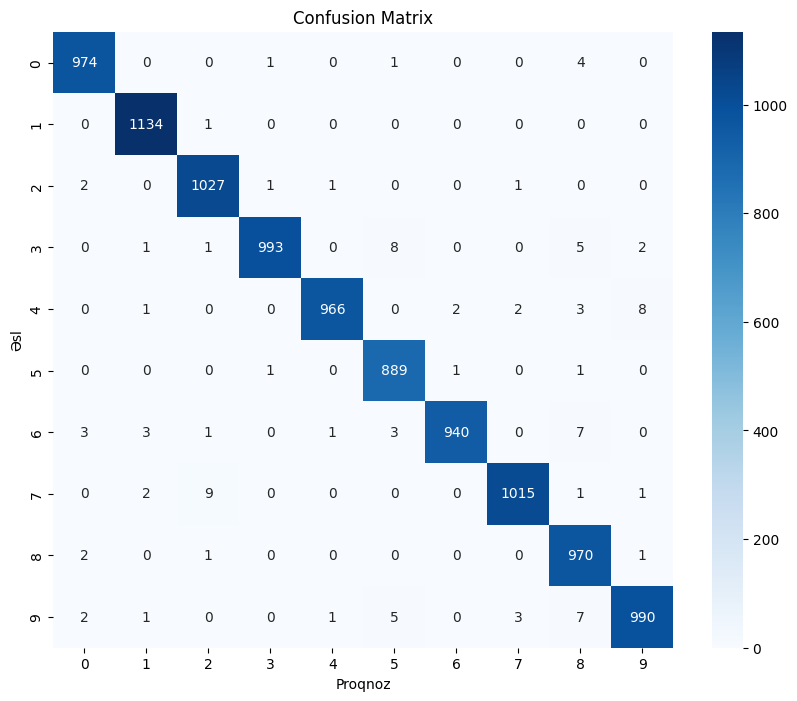

In [10]:
# 4) Confusion matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Proqnoz')
plt.ylabel('Əsl')
plt.title('Confusion Matrix')
plt.show()